In [108]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


In [166]:
from google.colab import files
uploaded = files.upload()


Saving realistic_movies.csv to realistic_movies.csv
Saving realistic_ratings.csv to realistic_ratings.csv
Saving streaming_churn_dataset.csv to streaming_churn_dataset (1).csv


In [123]:
df = pd.read_csv("streaming_churn_dataset.csv")

print(df.shape)
df.head()


(5000, 7)


,watch_time_per_day,last_login_days,genres_watched,skip_rate,engagement_score,binge_factor,Churn
0,139.868566,8,5,0.032345,77.534283,23.311428,0
1,114.469428,1,6,0.646928,67.134714,16.352775,0
2,145.907542,24,8,0.554295,76.353771,16.211949,0
3,180.921194,22,8,0.666836,94.460597,20.102355,1
4,110.633865,4,5,0.930141,64.116933,18.438978,0


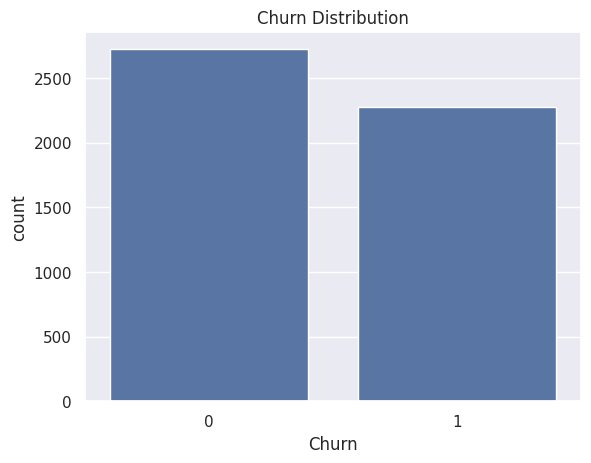

In [124]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


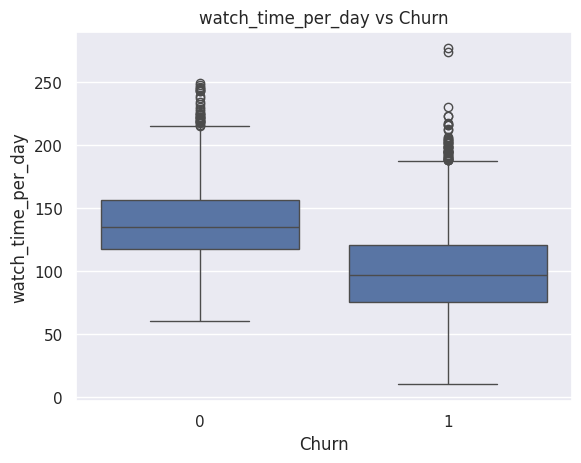

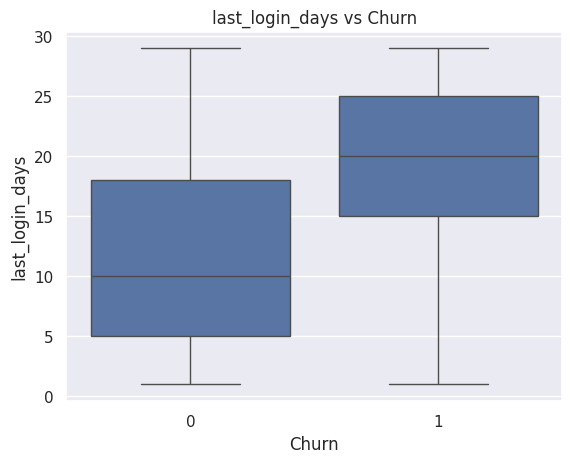

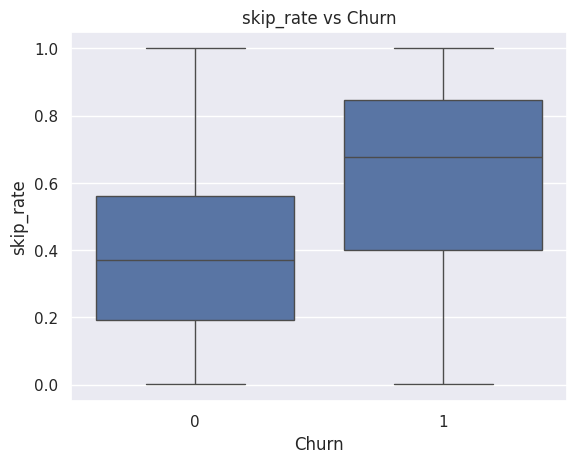

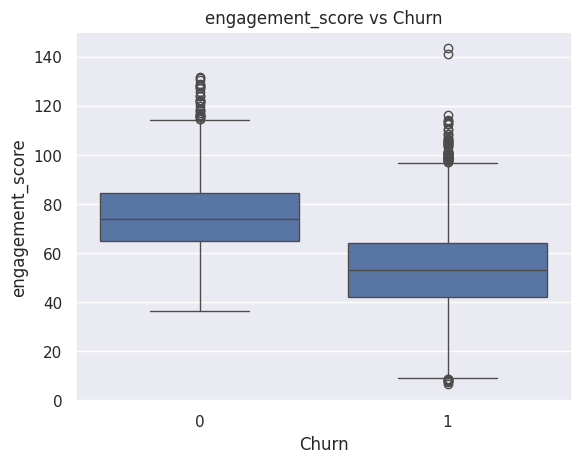

In [125]:
features = ["watch_time_per_day", "last_login_days", "skip_rate", "engagement_score"]

for col in features:
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()


In [126]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [127]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [128]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }


In [129]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="ROC-AUC", ascending=False)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,1.000,1.000000,1.000000,1.000000,1.000000
Gradient Boosting,0.998,1.000000,0.995575,0.997783,1.000000
Logistic Regression,0.869,0.854305,0.856195,0.855249,0.945538


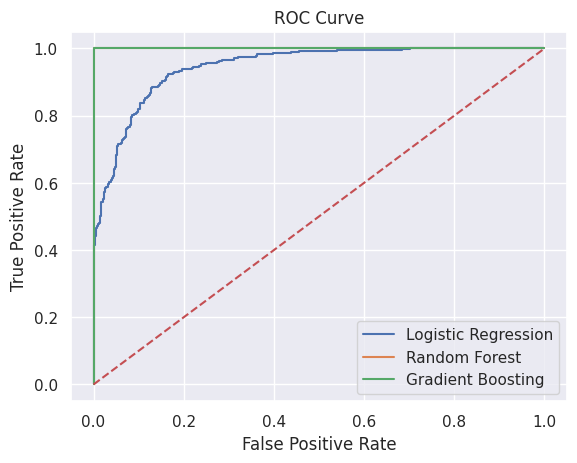

In [130]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


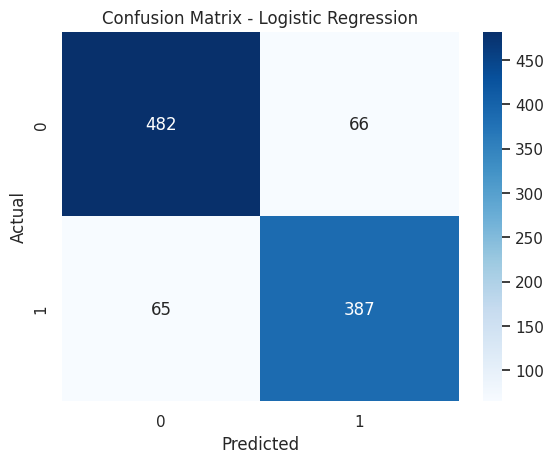

In [138]:
best_model = lr   # FORCE Logistic Regression

best_model = models["Logistic Regression"]

best_model_name = "Logistic Regression"

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [142]:
print(feature_importance.sort_values(ascending=False))


last_login_days       1.901655
skip_rate             1.895734
engagement_score      1.285079
watch_time_per_day    1.053915
binge_factor          0.177771
genres_watched        0.122623
dtype: float64


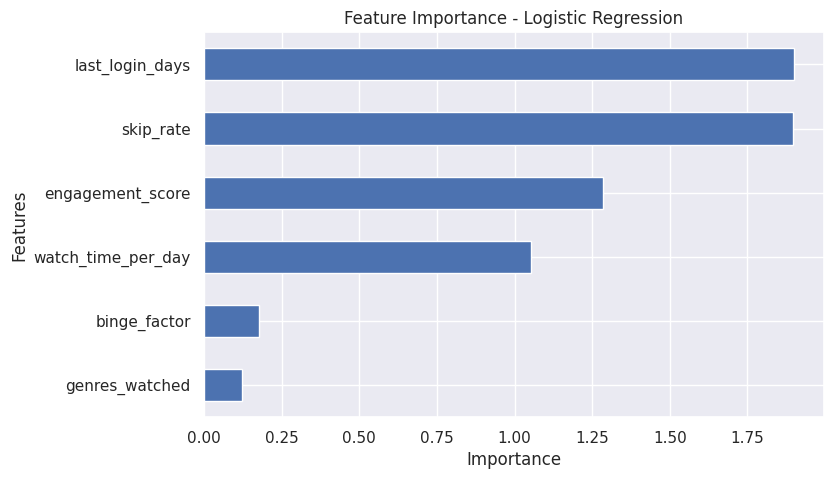

In [149]:

# -------------------------------
# FEATURE IMPORTANCE (FIXED)
# -------------------------------

if hasattr(best_model, "feature_importances_"):
    # Tree models (RF, GB)
    importance = best_model.feature_importances_

elif hasattr(best_model, "coef_"):
    # Logistic Regression
    importance = np.abs(best_model.coef_[0])

else:
    print("Model does not support feature importance")
    importance = None

# -------------------------------
# PLOT
# -------------------------------

if importance is not None:
    feature_importance = pd.Series(importance, index=X.columns)
    feature_importance = feature_importance.sort_values(ascending=True)

    plt.figure(figsize=(8,5))
    feature_importance.plot(kind="barh")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()


/tmp/ipython-input-2390678445.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar")


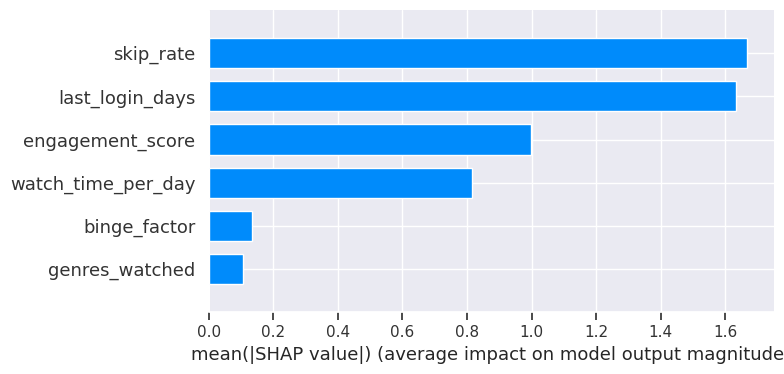

In [152]:
import shap

# Convert scaled data → DataFrame (THIS IS THE KEY FIX)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# SHAP explainer
explainer = shap.Explainer(best_model, X_train_scaled_df)

# SHAP values
shap_values = explainer(X_test_scaled_df)

# Plot
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar")


In [153]:


importance = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.Series(importance, index=X_test.columns).sort_values(ascending=False)

print("🔥 Top Features Affecting Churn:\n")
print(feature_importance)


🔥 Top Features Affecting Churn:

skip_rate             1.667815
last_login_days       1.634275
engagement_score      0.999108
watch_time_per_day    0.816430
binge_factor          0.135053
genres_watched        0.104822
dtype: float64


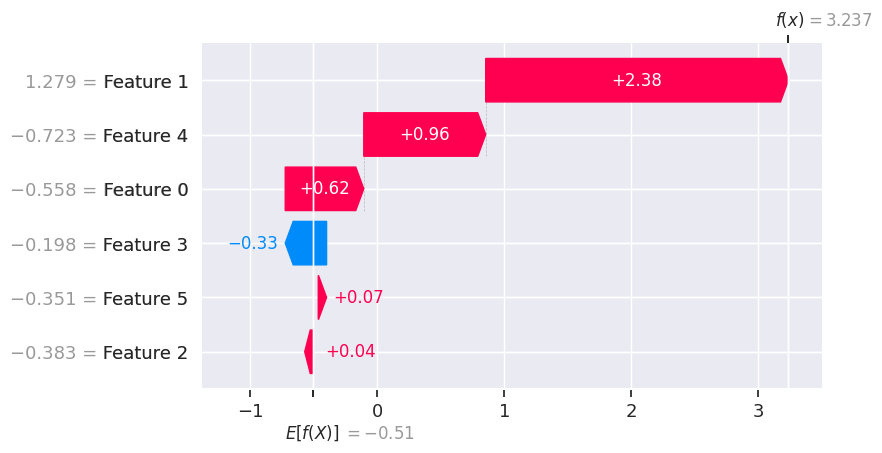

In [145]:
# Pick one user
i = 0

shap.plots.waterfall(shap_values[i])


In [154]:
import joblib

joblib.dump(best_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")


['feature_columns.pkl']

In [ ]:
from google.colab import files

files.download("models/churn_model.pkl")
files.download("models/scaler.pkl")
files.download("models/feature_columns.pkl")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>